In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

# --- Meteorological: hourly observations ---
# Keeping: temp, rhum, prcp, wspd, pres, wdir — dropping sparse/derived cols (snwd, wpgt, tsun, cldc, coco, wchill)
WEATHER_COLS = ["temp", "rhum", "prcp", "wspd", "pres", "wdir"]
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

# --- Merge on hour ---
df = pd.merge(elec.rename(columns={"timestamp": "time"}), met, on="time", how="inner")
df = df.sort_values("time").reset_index(drop=True)

print(f"Merged range: {df['time'].min()} → {df['time'].max()}")
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Merged range: 2022-01-01 00:00:00 → 2026-03-31 23:00:00
Rows: 37,168  |  Columns: ['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres']


,time,kwh,temp,rhum,prcp,wdir,wspd,pres
0,2022-01-01 00:00:00,1.236,2.0,96,0.2,102.0,6.8,1016.0
1,2022-01-01 01:00:00,1.898,1.7,96,0.3,0.0,0.0,1015.6
2,2022-01-01 02:00:00,1.611,1.1,100,NaN,0.0,0.0,1015.3
3,2022-01-01 03:00:00,1.522,1.7,100,0.8,0.0,0.0,1015.0
4,2022-01-01 04:00:00,1.709,1.7,96,0.8,0.0,0.0,1015.0


In [2]:
# --- Time features (no year) ---
df["hour"]       = df["time"].dt.hour
df["dayofweek"]  = df["time"].dt.dayofweek   # 0=Mon … 6=Sun
df["month"]      = df["time"].dt.month

# --- Temp lag features ---
df["temp_lag1"]  = df["temp"].shift(1)
df["temp_lag3"]  = df["temp"].shift(3)
df["temp_lag6"] = df["temp"].shift(6)

# --- kwh lag features ---
df["kwh_lag1"]  = df["kwh"].shift(1)
df["kwh_lag3"]  = df["kwh"].shift(3)
df["kwh_lag6"]  = df["kwh"].shift(6)

# Waking hour features
df['awake'] = ((df['hour'] >= 6) & (df['hour'] <= 23)).astype(int)

# Drop missing weather values
n_rows = len(df.index)
df = df.dropna(axis=0)
print(f'Dropped: {(n_rows - len(df.index))/n_rows:0.2%} of rows')
df.head()

Dropped: 5.87% of rows


,time,kwh,temp,rhum,prcp,wdir,wspd,pres,hour,dayofweek,month,temp_lag1,temp_lag3,temp_lag6,kwh_lag1,kwh_lag3,kwh_lag6,awake
6,2022-01-01 06:00:00,1.887,1.7,96,0.0,0.0,0.0,1014.4,6,5,1,2.2,1.7,2.0,1.857,1.522,1.236,1
7,2022-01-01 07:00:00,1.959,1.7,100,0.0,0.0,0.0,1015.0,7,5,1,1.7,1.7,1.7,1.887,1.709,1.898,1
8,2022-01-01 08:00:00,2.054,1.7,96,0.0,0.0,0.0,1014.7,8,5,1,1.7,2.2,1.1,1.959,1.857,1.611,1
9,2022-01-01 09:00:00,2.014,1.7,100,0.0,0.0,0.0,1014.6,9,5,1,1.7,1.7,1.7,2.054,1.887,1.522,1
10,2022-01-01 10:00:00,1.931,1.7,100,0.0,0.0,0.0,1013.9,10,5,1,1.7,1.7,1.7,2.014,1.959,1.709,1


In [3]:
import numpy as np

def cyclical_encode(values, period):
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dayofweek_sin"],  df["dayofweek_cos"]  = cyclical_encode(df["dayofweek"], 7)
df["month_sin"],  df["month_cos"]  = cyclical_encode(df["month"], 12)
df["wdir_sin"], df["wdir_cos"] = cyclical_encode(df["wdir"], 360)


In [ ]:
OVERNIGHT_ONLY = False

if OVERNIGHT_ONLY:
    df = df[df["awake"] == 0]

FEATURE_COLS = [
    'temp',
    'rhum', 
    'prcp', 
    'wspd', 
    #'pres', 
    'wdir_sin',
    'wdir_cos',
    'temp_lag1', 
    'temp_lag3', 
    'temp_lag6',
    'kwh_lag1', 
    'kwh_lag3',
    "kwh_lag6", 
    #'hour_sin', 'hour_cos'
    ]
TARGET_COL   = "kwh"

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

# Sequential separation to prevent data leakage
split_idx = int(len(X) * 0.75)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_test_s = scaler_y.fit_transform(y_test.reshape(-1, 1))

print(f"Features:      {FEATURE_COLS}")
print(f"X_train shape: {X_train_s.shape}")
print(f"X_test shape:  {X_test_s.shape}")
print(f"y_train shape: {y_train_s.shape}  (mean={y_train.mean():.3f} kWh, std={y_train.std():.3f})")
print(f"y_test  shape: {y_test_s.shape}  (mean={y_test.mean():.3f} kWh, std={y_test.std():.3f})")

Features:      ['temp', 'rhum', 'prcp', 'wspd', 'wdir_sin', 'wdir_cos', 'temp_lag1', 'temp_lag3', 'temp_lag6', 'kwh_lag1', 'kwh_lag3', 'kwh_lag6']
X_train shape: (26239, 12)
X_test shape:  (8747, 12)
y_train shape: (26239, 1)  (mean=1.425 kWh, std=1.292)
y_test  shape: (8747, 1)  (mean=1.735 kWh, std=1.398)


In [5]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s, dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Model
class MLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64),  # input layer: n_features → 12 neurons
            nn.ReLU(),                  # activation: zero out negatives
            nn.Dropout(0.2),            # randomly zero 20% of neurons during training (regularization)
            nn.Linear(64, 32),          # hidden layer: 64 → 32 neurons
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)            # output layer: 32 → 1 (predicted kWh)
        )
    
    def forward(self, x):
        return self.net(x)              # forward pass: input flows through all layers sequentially


In [6]:
model = MLP(X_train_t.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

n_epochs = 200
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    scheduler.step(test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


Epoch  10 | Test MSE: 0.3999 | LR: 0.001000
Epoch  20 | Test MSE: 0.3664 | LR: 0.001000
Epoch  30 | Test MSE: 0.3782 | LR: 0.001000
Epoch  40 | Test MSE: 0.3759 | LR: 0.001000
Epoch  50 | Test MSE: 0.3679 | LR: 0.001000
Epoch  60 | Test MSE: 0.3802 | LR: 0.001000
Epoch  70 | Test MSE: 0.3649 | LR: 0.001000
Epoch  80 | Test MSE: 0.3716 | LR: 0.000500
Epoch  90 | Test MSE: 0.3643 | LR: 0.000500
Epoch 100 | Test MSE: 0.3694 | LR: 0.000250
Epoch 110 | Test MSE: 0.3721 | LR: 0.000250
Epoch 120 | Test MSE: 0.3700 | LR: 0.000125
Epoch 130 | Test MSE: 0.3740 | LR: 0.000125
Epoch 140 | Test MSE: 0.3788 | LR: 0.000063
Epoch 150 | Test MSE: 0.3751 | LR: 0.000063
Epoch 160 | Test MSE: 0.3710 | LR: 0.000063
Epoch 170 | Test MSE: 0.3720 | LR: 0.000031
Epoch 180 | Test MSE: 0.3714 | LR: 0.000031
Epoch 190 | Test MSE: 0.3731 | LR: 0.000016
Epoch 200 | Test MSE: 0.3735 | LR: 0.000016


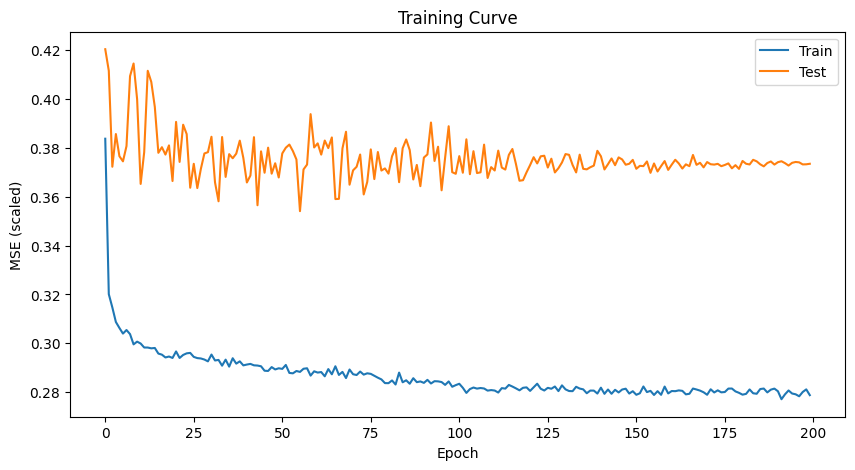

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Training Curve')
plt.show()

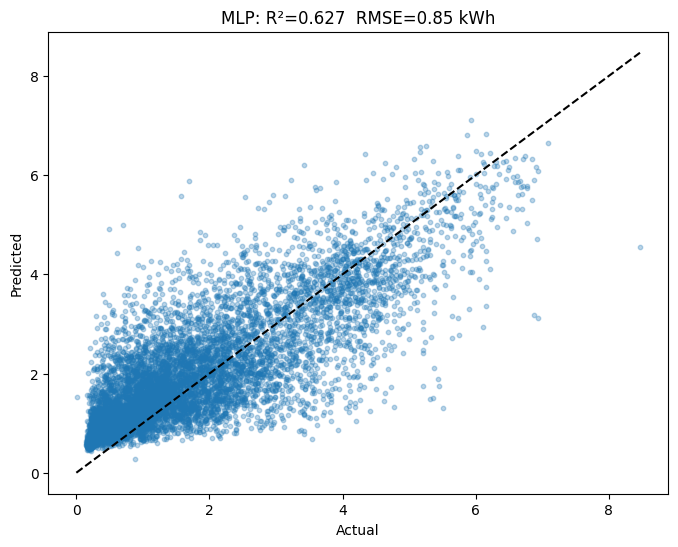

In [8]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()
    pred_kwh = scaler_y.inverse_transform(pred_scaled)

from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, pred_kwh))
r2 = r2_score(y_test, pred_kwh)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_kwh, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'k--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'MLP: R²={r2:.3f}  RMSE={rmse:.2f} kWh')
plt.show()